# B-matrix analysis at single-cell resolution

Snakemake projects every raw cell into the full-data CLAMPfull model using the pseudobulk training mean and variance. This notebook loads the saved LV scores; it performs no export, normalization, or projection. For each benchmark-assigned LV, recovery is evaluated in the exact top 1% of all projected cells.

In [1]:
from pathlib import Path
import h5py, yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyprojroot import here
ROOT=Path(here())
with open(ROOT/'workflow/config/pseudobulk.yaml') as handle: CONFIG=yaml.safe_load(handle)
DATASETS=list(CONFIG['datasets'])
PROD=ROOT/CONFIG['paths']['production']
OUT=ROOT/CONFIG['paths']['biology']/'03_b_matrix_singlecell'
ASSIGNMENTS=ROOT/CONFIG['paths']['biology']/'00_benchmark/clampfull_lv_assignments.csv'
TOP_FRACTION=float(CONFIG['projection']['top_fraction'])
OUT.mkdir(parents=True,exist_ok=True)
def decode(values):
    return np.array([x.decode() if isinstance(x,bytes) else str(x) for x in values],dtype=str)

In [2]:
benchmark=pd.read_csv(ASSIGNMENTS)
heatmaps=[]; recoveries=[]; assignment_rows=[]
for dataset in DATASETS:
    assigned=benchmark.loc[benchmark.dataset==dataset,['cell_type','LV','cor']].copy()
    path=PROD/dataset/'single_cell_projection/single_cell_lv_scores.h5'
    with h5py.File(path,'r') as h5:
        lv_names=decode(h5['lv_names'][:]).tolist(); lv_index={lv:i for i,lv in enumerate(lv_names)}
        mapped=decode(h5['mapped_cell_type'][:]); scores=h5['scores'][:]; n_cells=scores.shape[0]
        n_top=max(1,int(np.ceil(n_cells*TOP_FRACTION)))
        assigned_types=assigned.cell_type.tolist()
        observed_types=sorted(x for x in np.unique(mapped) if x)
        row_types=assigned_types+[x for x in observed_types if x not in assigned_types]
        counts=pd.DataFrame(0,index=row_types,columns=assigned_types,dtype=int)
        for row in assigned.itertuples(index=False):
            if row.LV not in lv_index: continue
            values=scores[:,lv_index[row.LV]]
            top=np.argpartition(-values,n_top-1)[:n_top]
            observed=pd.Series(mapped[top]).value_counts()
            for truth_type in row_types: counts.loc[truth_type,row.cell_type]=int(observed.get(truth_type,0))
        purity=counts/n_top*100
        population=pd.Series(mapped).value_counts(); n_population=n_cells
        prevalence=population.reindex(row_types).fillna(0)/max(n_population,1)
        lift=purity.div(100).div(prevalence.replace(0,np.nan),axis=0)
        long=purity.stack().rename('pct').reset_index(); long.columns=['row_cell_type','col_cell_type','pct']
        long['count']=counts.stack().to_numpy(); long['lift']=lift.stack(dropna=False).to_numpy(); long['dataset']=dataset
        heatmaps.append(long)
        for row in assigned.itertuples(index=False):
            ct=row.cell_type; observed=purity.loc[ct,ct]/100; n_true=int(population.get(ct,0))
            max_achievable=min(1,n_true/n_top); prev=float(prevalence[ct])
            recoveries.append({'dataset':dataset,'cell_type':ct,'n_top':n_top,'col_pool_size':n_top,
              'diag_count':int(counts.loc[ct,ct]),'recovery_pct':observed*100,'assigned_lv':row.LV,
              'assignment_cor':row.cor,'n_true_cells':n_true,'n_population':n_population,'prevalence':prev,
              'max_achievable_purity':max_achievable,
              'purity_ratio':observed/max_achievable if max_achievable>0 else np.nan,
              'purity_lift':observed/prev if prev>0 else np.nan})
        assigned.insert(0,'dataset_output',dataset); assignment_rows.append(assigned)
heatmap_long=pd.concat(heatmaps,ignore_index=True); recovery=pd.DataFrame(recoveries)
assignments=pd.concat(assignment_rows,ignore_index=True).drop(columns='dataset_output')
purity_corrected=recovery.rename(columns={'prevalence':'prevalence_fraction','max_achievable_purity':'max_achievable_fraction'})
per_dataset=recovery.groupby('dataset').recovery_pct.mean()
overall=pd.DataFrame({'scope':['canonical_6datasets']*4,'metric':['global_recovery_pct_pooled','mean_recovery_pct_by_dataset','mean_purity_ratio','mean_purity_lift'],
 'value':[recovery.diag_count.sum()/recovery.n_top.sum()*100,per_dataset.mean(),recovery.purity_ratio.mean(),recovery.purity_lift.mean()]})
heatmap_long.to_csv(OUT/'heatmap_long.csv',index=False); recovery.to_csv(OUT/'recovery_summary.csv',index=False)
purity_corrected.to_csv(OUT/'purity_corrected_summary.csv',index=False); assignments.to_csv(OUT/'lv_assignments.csv',index=False)
overall.to_csv(OUT/'recovery_overall.csv',index=False)
overall

/tmp/ipykernel_3854126/278577551.py:25: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long['count']=counts.stack().to_numpy(); long['lift']=lift.stack(dropna=False).to_numpy(); long['dataset']=dataset


/tmp/ipykernel_3854126/278577551.py:25: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long['count']=counts.stack().to_numpy(); long['lift']=lift.stack(dropna=False).to_numpy(); long['dataset']=dataset


/tmp/ipykernel_3854126/278577551.py:25: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long['count']=counts.stack().to_numpy(); long['lift']=lift.stack(dropna=False).to_numpy(); long['dataset']=dataset


/tmp/ipykernel_3854126/278577551.py:25: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long['count']=counts.stack().to_numpy(); long['lift']=lift.stack(dropna=False).to_numpy(); long['dataset']=dataset


/tmp/ipykernel_3854126/278577551.py:25: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long['count']=counts.stack().to_numpy(); long['lift']=lift.stack(dropna=False).to_numpy(); long['dataset']=dataset


/tmp/ipykernel_3854126/278577551.py:25: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long['count']=counts.stack().to_numpy(); long['lift']=lift.stack(dropna=False).to_numpy(); long['dataset']=dataset


,scope,metric,value
0,canonical_6datasets,global_recovery_pct_pooled,66.067952
1,canonical_6datasets,mean_recovery_pct_by_dataset,73.549190
2,canonical_6datasets,mean_purity_ratio,0.744365
3,canonical_6datasets,mean_purity_lift,18.627171


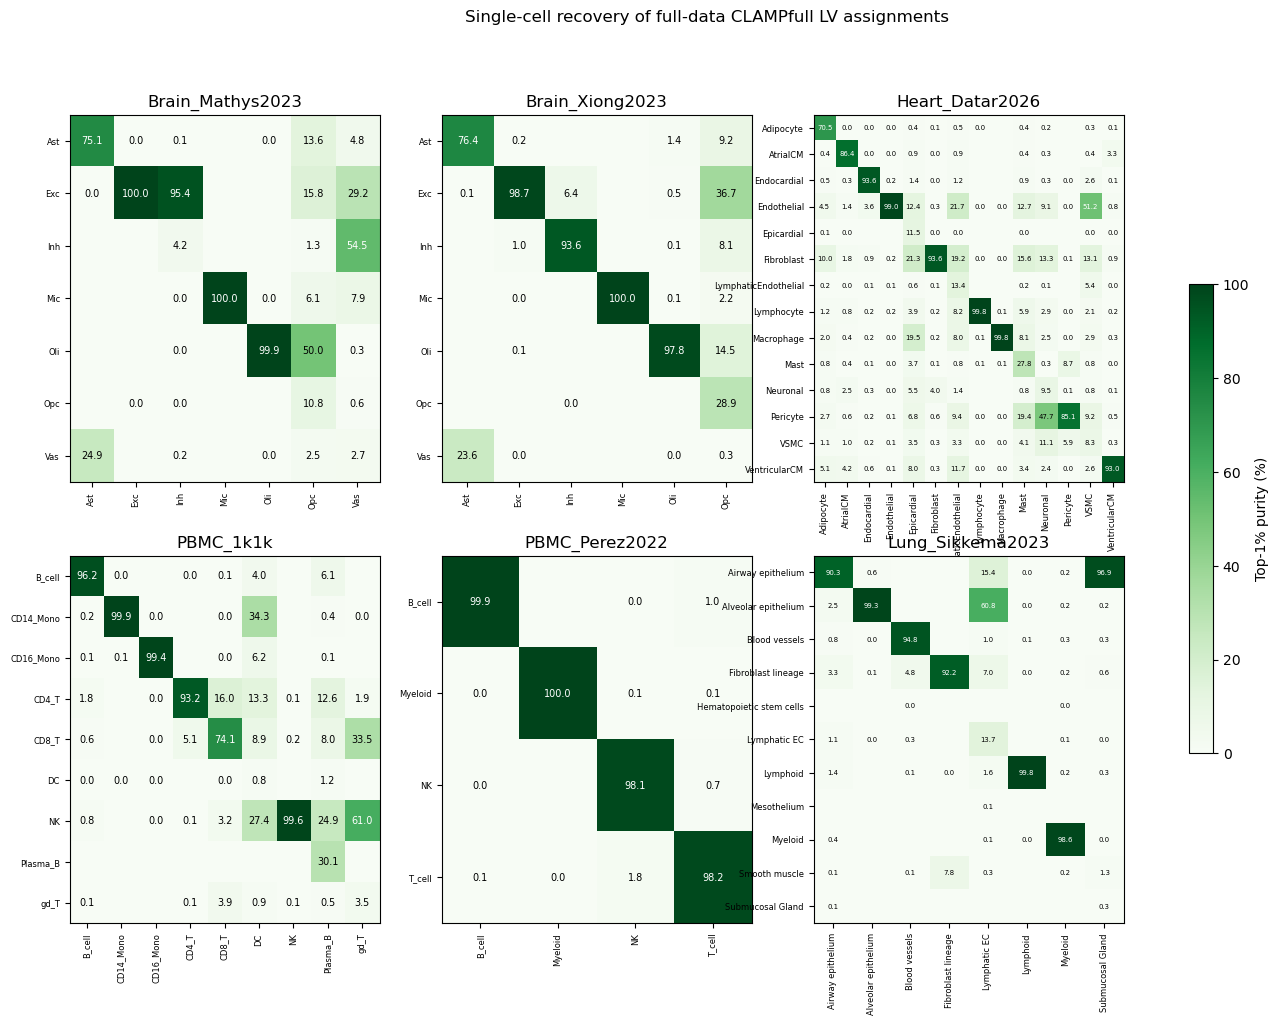

In [3]:
fig,axes=plt.subplots(2,3,figsize=(17,10.5)); image=None
for ax,dataset in zip(axes.flat,DATASETS):
    d=heatmap_long[heatmap_long.dataset==dataset]
    mat=d.pivot(index='row_cell_type',columns='col_cell_type',values='pct').fillna(0)
    image=ax.imshow(mat.values,vmin=0,vmax=100,cmap='Greens',aspect='auto')
    size=5 if max(mat.shape)>10 else 7
    for i in range(mat.shape[0]):
      for j in range(mat.shape[1]):
        value=mat.iat[i,j]
        if value>0: ax.text(j,i,f'{value:.1f}',ha='center',va='center',fontsize=size,color='white' if value>=50 else 'black')
    ax.set_title(dataset); ax.set_xticks(range(len(mat.columns)),mat.columns,rotation=90,fontsize=6)
    ax.set_yticks(range(len(mat.index)),mat.index,fontsize=6)
fig.colorbar(image,ax=axes.ravel().tolist(),label='Top-1% purity (%)',shrink=.58)
fig.suptitle('Single-cell recovery of full-data CLAMPfull LV assignments')
fig.savefig(OUT/'single_cell_recovery_heatmaps.png',dpi=160,bbox_inches='tight')
plt.show()